In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, roc_auc_score, silhouette_score, adjusted_rand_score)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
RANDOM_STATE = SEED

# Preliminar

In [2]:
csv_local = "data.csv"  

df = pd.read_csv(csv_local)

# drop id and unnamed 32:
df = df.drop(columns=['id'])
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Mostrar primeras filas y shape
print(df.shape)
df.head()

(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Parte (a)

In [3]:
var = df.copy()
# drop categorical columns
var = var.select_dtypes(include=[np.number])
var_list = var.var().sort_values(ascending=False).head(10)
var_list.round(2)

area_worst         324167.39
area_mean          123843.55
area_se              2069.43
perimeter_worst      1129.13
perimeter_mean        590.44
texture_worst          37.78
radius_worst           23.36
texture_mean           18.50
radius_mean            12.42
perimeter_se            4.09
dtype: float64

In [4]:
# variables continuas a categorizar
vars = ["area_worst", "area_mean", "area_se"]

for v in vars:
    print(f"\nCategorizing variable: {v}")
    df[v + '_cat'] = pd.qcut(df[v], q=3, labels=['low', 'mid', 'high'])
    df[v + '_cat'] = df[v + '_cat'].astype('category')
    print(df[[v, v + '_cat']].head())

# Verificar cambios
df[vars + [v + '_cat' for v in vars]].head()  


Categorizing variable: area_worst
   area_worst area_worst_cat
0      2019.0           high
1      1956.0           high
2      1709.0           high
3       567.7            mid
4      1575.0           high

Categorizing variable: area_mean
   area_mean area_mean_cat
0     1001.0          high
1     1326.0          high
2     1203.0          high
3      386.1           low
4     1297.0          high

Categorizing variable: area_se
   area_se area_se_cat
0   153.40        high
1    74.08        high
2    94.03        high
3    27.23         mid
4    94.44        high


,area_worst,area_mean,area_se,area_worst_cat,area_mean_cat,area_se_cat
0,2019.0,1001.0,153.40,high,high,high
1,1956.0,1326.0,74.08,high,high,high
2,1709.0,1203.0,94.03,high,high,high
3,567.7,386.1,27.23,mid,low,mid
4,1575.0,1297.0,94.44,high,high,high


In [5]:
# Columnas del dataframe
df.columns.tolist()

['diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'area_worst_cat',
 'area_mean_cat',
 'area_se_cat']

## Parte (b)


Top correlaciones - _mean


,Variable 1,Variable 2,Correlación
0,radius_mean,perimeter_mean,0.997855
1,radius_mean,area_mean,0.987357
2,perimeter_mean,area_mean,0.986507
3,concavity_mean,concave points_mean,0.921391
4,compactness_mean,concavity_mean,0.883121



Top correlaciones - _se


,Variable 1,Variable 2,Correlación
0,radius_se,perimeter_se,0.972794
1,radius_se,area_se,0.951830
2,perimeter_se,area_se,0.937655
3,compactness_se,fractal_dimension_se,0.803269
4,compactness_se,concavity_se,0.801268



Top correlaciones - _worst


,Variable 1,Variable 2,Correlación
0,radius_worst,perimeter_worst,0.993708
1,radius_worst,area_worst,0.984015
2,perimeter_worst,area_worst,0.977578
3,compactness_worst,concavity_worst,0.892261
4,concavity_worst,concave points_worst,0.855434


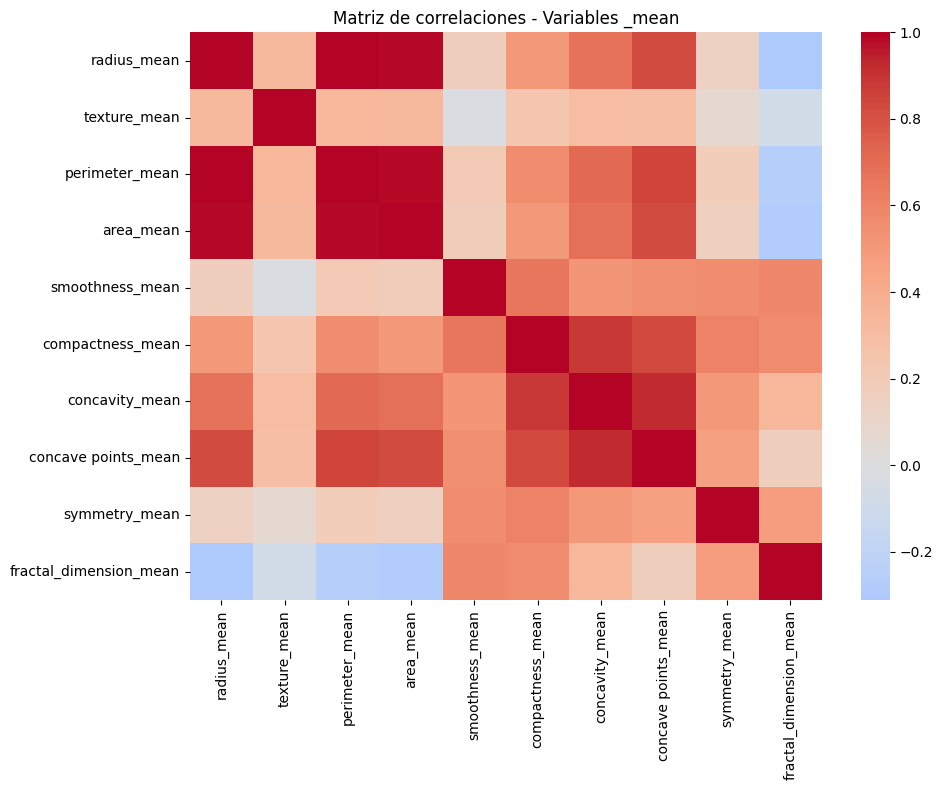

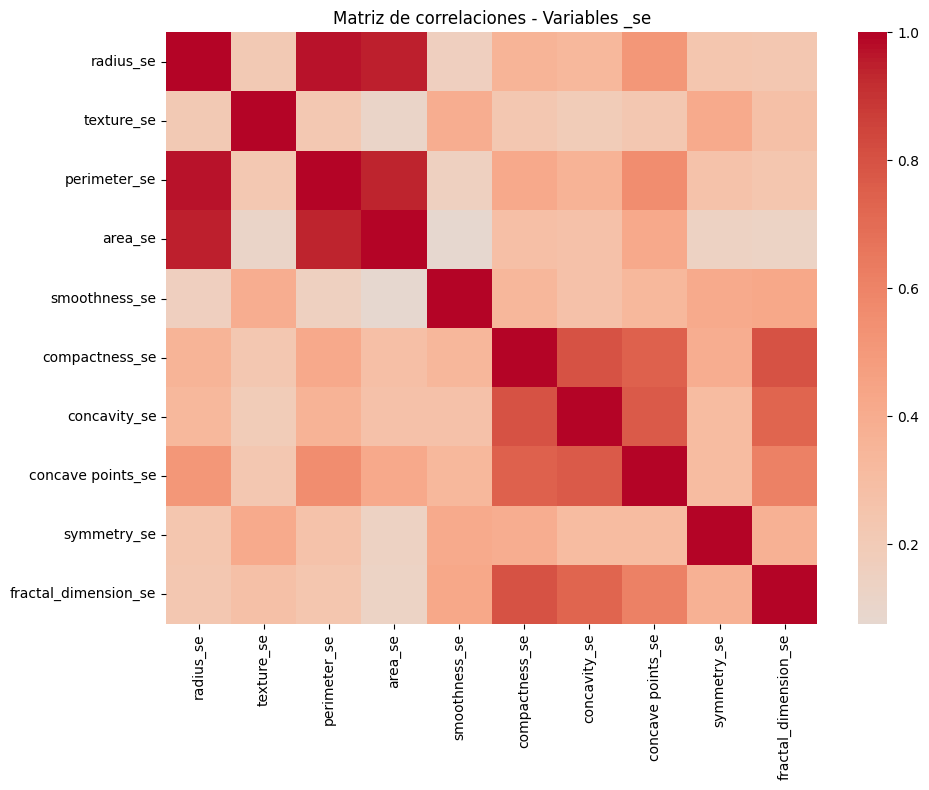

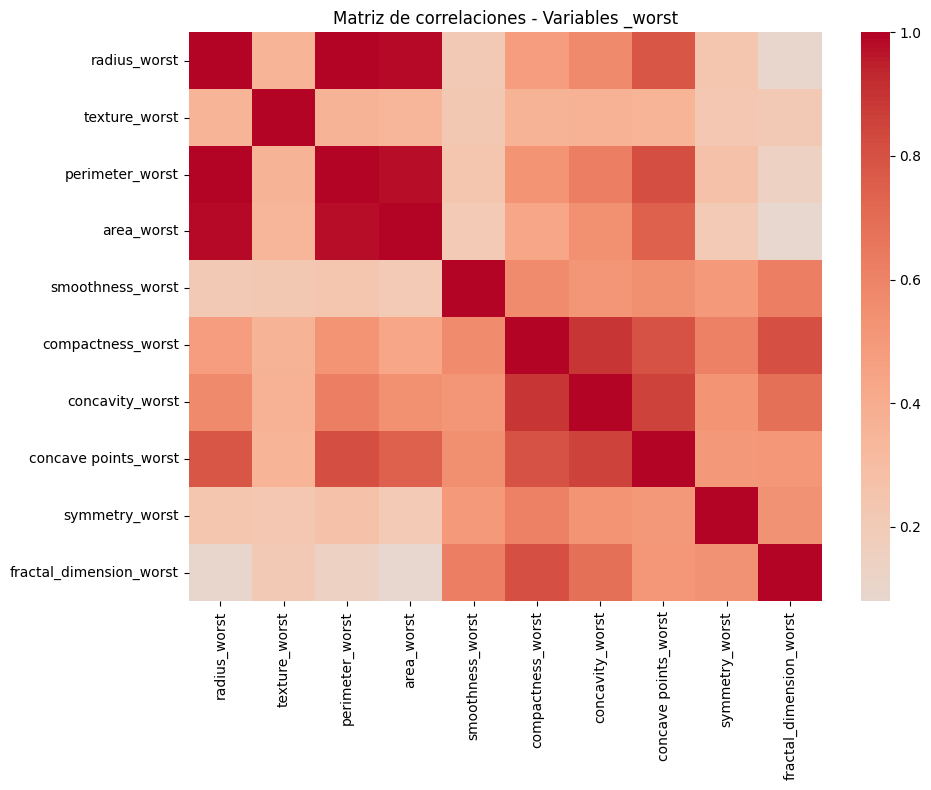

In [6]:
# Filtrar solo columnas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns

# Clasificar columnas numéricas por sufijos
mean_cols  = [c for c in num_cols if c.endswith('_mean')]
se_cols    = [c for c in num_cols if c.endswith('_se')]
worst_cols = [c for c in num_cols if c.endswith('_worst')]

# Calcular matrices de correlación
corr_mean  = df[mean_cols].corr()  if len(mean_cols)  > 1 else None
corr_se    = df[se_cols].corr()    if len(se_cols)    > 1 else None
corr_worst = df[worst_cols].corr() if len(worst_cols) > 1 else None

# Función para mostrar top correlaciones
def mostrar_top_correlaciones(corr_matrix, titulo):
    if corr_matrix is None:
        print(f"\n{titulo}: No hay suficientes columnas numéricas.")
        return
    
    # Obtener pares superiores (sin la diagonal)
    corr_pairs = (
        corr_matrix.where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))
        .stack()
        .sort_values(ascending=False)
    )

    # Convertir MultiIndex → DataFrame normal
    df_pairs = corr_pairs.reset_index()
    df_pairs.columns = ["Variable 1", "Variable 2", "Correlación"]

    print(f"\n{'='*20}\n{titulo}\n{'='*20}")
    display(df_pairs.head(5))

# Mostrar top correlaciones
mostrar_top_correlaciones(corr_mean,  "Top correlaciones - _mean")
mostrar_top_correlaciones(corr_se,    "Top correlaciones - _se")
mostrar_top_correlaciones(corr_worst, "Top correlaciones - _worst")

# Heatmap para _mean
if corr_mean is not None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_mean, cmap="coolwarm", center=0, annot=False)
    plt.title("Matriz de correlaciones - Variables _mean")
    plt.tight_layout()
    plt.show()

# Heatmap para _se
if corr_se is not None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_se, cmap="coolwarm", center=0, annot=False)
    plt.title("Matriz de correlaciones - Variables _se")
    plt.tight_layout()
    plt.show()

# Heatmap para _worst
if corr_worst is not None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_worst, cmap="coolwarm", center=0, annot=False)
    plt.title("Matriz de correlaciones - Variables _worst")
    plt.tight_layout()
    plt.show()

# Clusterización

## Parte (c)

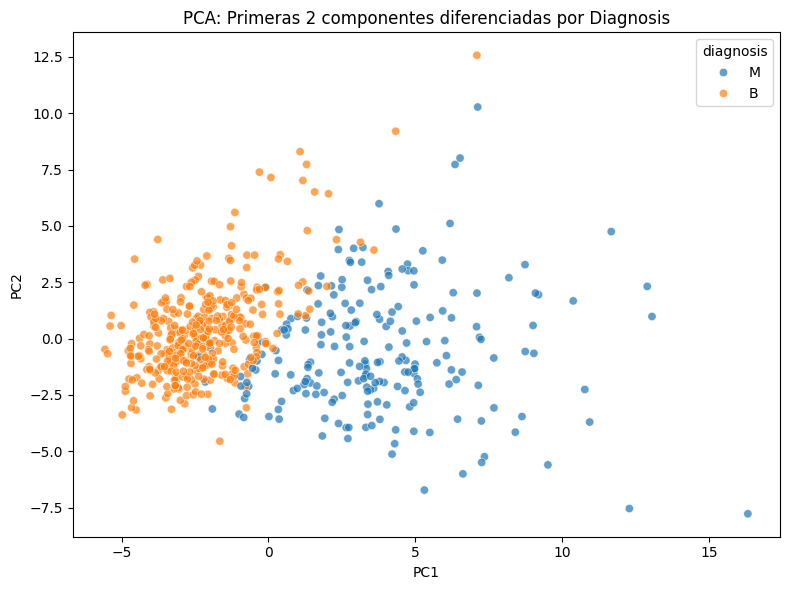

Explained variance ratio (PC1, PC2): [0.44272026 0.18971182]


In [7]:
# Preparar datos numéricos para PCA
X = df.select_dtypes(include=[np.number]).copy()
# Convert categorical to one-hot
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['diagnosis'] = df['diagnosis'].values

# Plot PCA
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='diagnosis', alpha=0.7)
plt.title("PCA: Primeras 2 componentes diferenciadas por Diagnosis")
plt.tight_layout()
plt.show()

# Varianza explicada
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_)

## Parte (d)

- SSE por número de clusters
k = 2: SSE = 11595.53
k = 3: SSE = 10061.80
k = 4: SSE = 9258.99
k = 5: SSE = 8558.66
k = 6: SSE = 7970.26
k = 7: SSE = 7540.32
k = 8: SSE = 7254.33
k = 9: SSE = 6837.63
k = 10: SSE = 6603.40

- Silhouette Score por número de clusters
k = 2: Silhouette = 0.3434
k = 3: Silhouette = 0.3144
k = 4: Silhouette = 0.2833
k = 5: Silhouette = 0.1582
k = 6: Silhouette = 0.1604
k = 7: Silhouette = 0.1532
k = 8: Silhouette = 0.1472
k = 9: Silhouette = 0.1470
k = 10: Silhouette = 0.1367


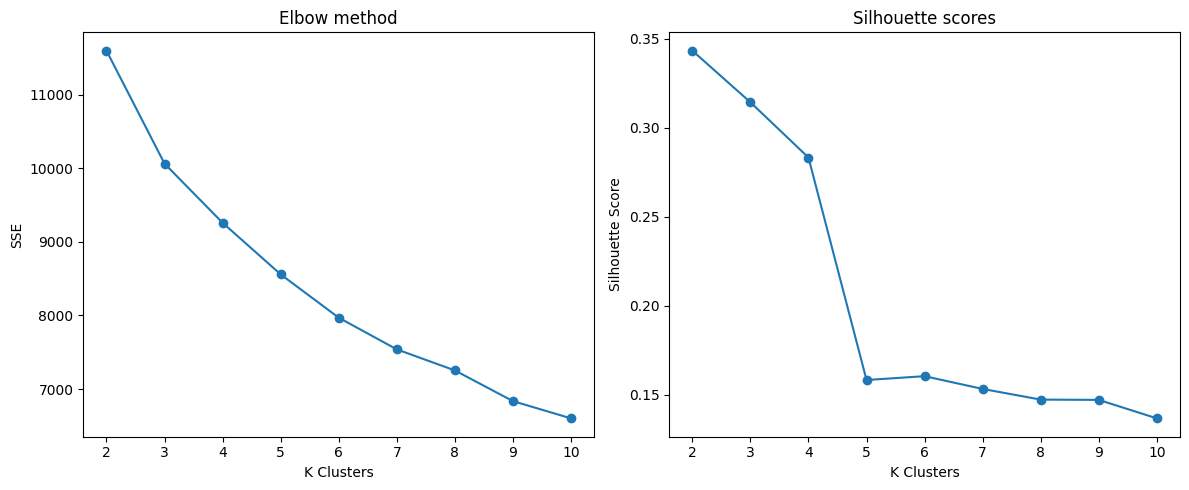

k=2, ARI=0.6536, Silhouette=0.3434


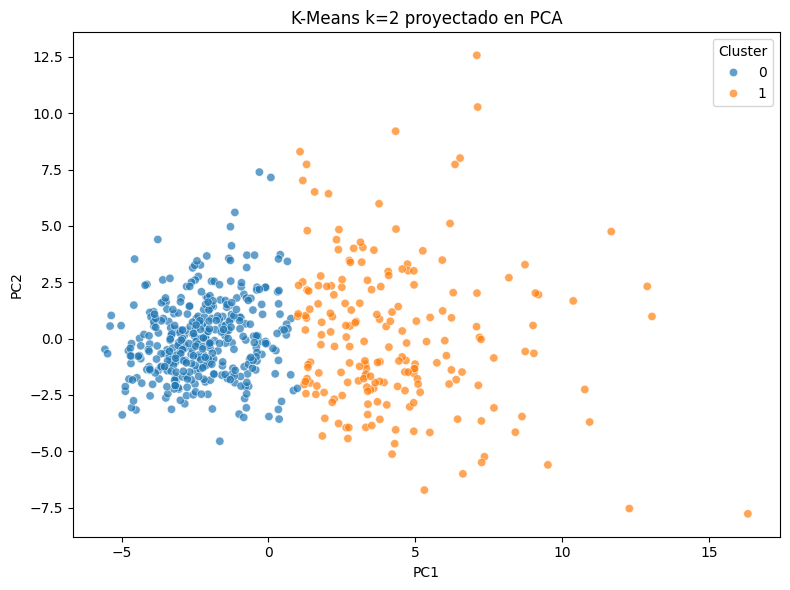

In [8]:
from sklearn.metrics import silhouette_score

sse = []
sil_scores = []
K_range = range(2,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    sse.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# Print SSE
print("- SSE por número de clusters")
for k, val in zip(K_range, sse):
    print(f"k = {k}: SSE = {val:.2f}")

# Print Silhouette
print("\n- Silhouette Score por número de clusters")
for k, val in zip(K_range, sil_scores):
    print(f"k = {k}: Silhouette = {val:.4f}")

# Plot Elbow y Silhouette
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, sse, '-o')
plt.xlabel('K Clusters')
plt.ylabel('SSE')
plt.title('Elbow method')

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, '-o')
plt.xlabel('K Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette scores')
plt.tight_layout()
plt.show()

# k = 2
k_chosen = 2
km = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
labels_km = km.fit_predict(X_scaled)

# ARI comparando con diagnosis (diagnosis a 0/1)
y_true = (df['diagnosis'].map(lambda x: 1 if x.lower().startswith('m') or 'mal' in x.lower() else 0)).values
ari = adjusted_rand_score(y_true, labels_km)
sil = silhouette_score(X_scaled, labels_km)
print(f"k={k_chosen}, ARI={ari:.4f}, Silhouette={sil:.4f}")

# Graficar clusters en PCA
pca_vis = pca_df.copy()
pca_vis['Cluster'] = labels_km
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_vis, x='PC1', y='PC2', hue='Cluster', palette='tab10', alpha=0.7)
plt.title(f'K-Means k={k_chosen} proyectado en PCA')
plt.tight_layout()
plt.show()

## Parte (e)

eps=0.5: clusters=0, noise=100.00, silhouette=nan, ARI=0.0000
eps=1.0: clusters=0, noise=100.00, silhouette=nan, ARI=0.0000
eps=1.5: clusters=1, noise=96.66, silhouette=nan, ARI=-0.0227
eps=1.7: clusters=1, noise=85.76, silhouette=nan, ARI=-0.0343
eps=1.8: clusters=2, noise=78.56, silhouette=-0.1445, ARI=0.0023
eps=1.9: clusters=4, noise=71.18, silhouette=-0.2102, ARI=0.0534
eps=2.0: clusters=4, noise=65.20, silhouette=-0.1985, ARI=0.0964


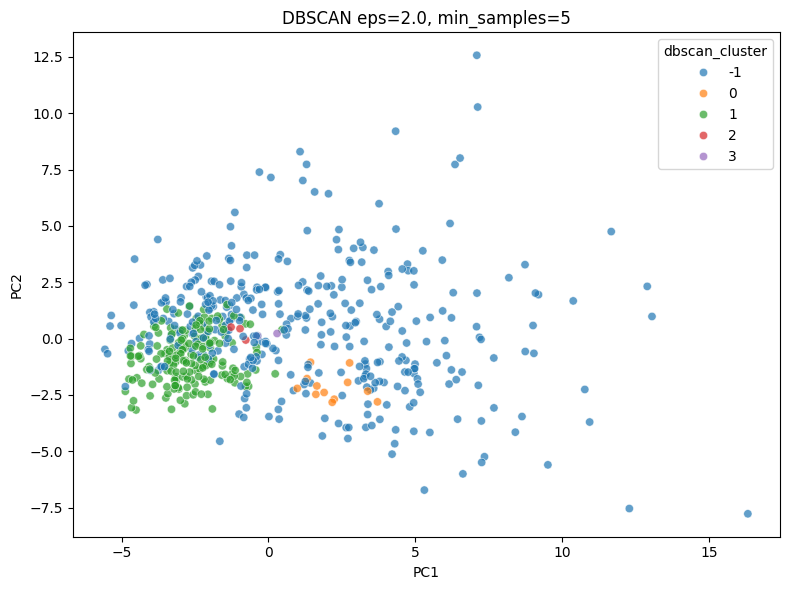

In [9]:
from sklearn.cluster import DBSCAN

# eps y min_samples
eps_values = [0.5, 1.0, 1.5, 1.7, 1.8, 1.9, 2.0]
min_samples = 5

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels_db = db.fit_predict(X_scaled)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = list(labels_db).count(-1)
    if len(set(labels_db)) > 1:
        sil = silhouette_score(X_scaled, labels_db) if n_clusters>1 else np.nan
        ari = adjusted_rand_score(y_true, labels_db)
    else:
        sil = np.nan
        ari = adjusted_rand_score(y_true, labels_db)
    
    noise_ratio = (n_noise / 569) * 100  
    print(f"eps={eps}: clusters={n_clusters}, noise={noise_ratio:.2f}, silhouette={sil:.4f}, ARI={ari:.4f}")

# Plot
eps_example = 2.0
db = DBSCAN(eps=eps_example, min_samples=min_samples)
labels_db = db.fit_predict(X_scaled)
pca_vis['dbscan_cluster'] = labels_db
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_vis, x='PC1', y='PC2', hue='dbscan_cluster', palette='tab10', alpha=0.7)
plt.title(f'DBSCAN eps={eps_example}, min_samples={min_samples}')
plt.tight_layout()
plt.show()


## Parte (f)

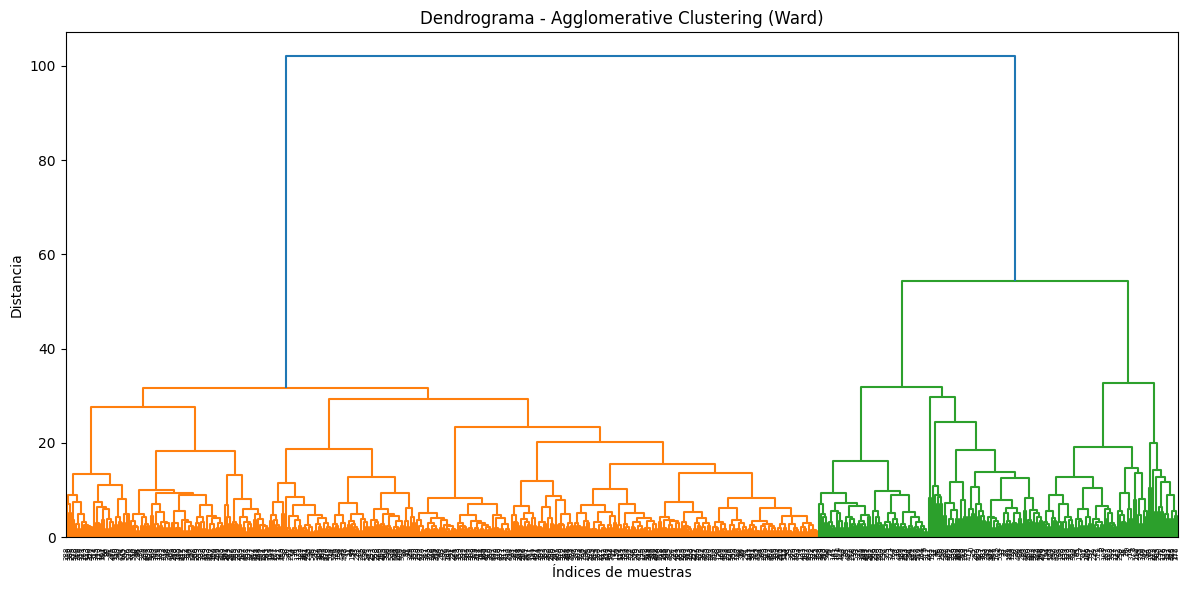

k=2, ARI=0.5750, Silhouette=0.3394
k=3, ARI=0.5363, Silhouette=0.3301
k=4, ARI=0.5434, Silhouette=0.2982
k=5, ARI=0.5038, Silhouette=0.2434
k=6, ARI=0.2865, Silhouette=0.1199
ARI (hierarchical): 0.5750409366326297


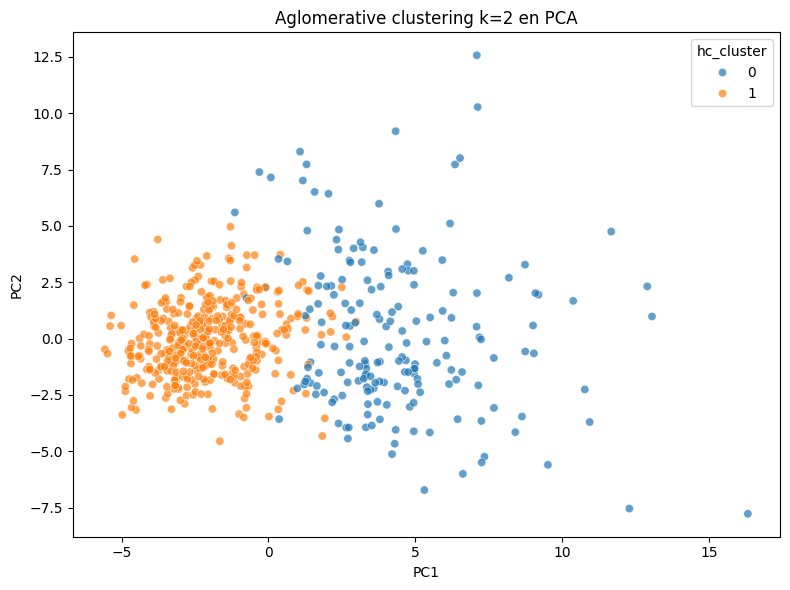

In [ ]:
# linkage 
Z = linkage(X_scaled, method='ward')

# Dendrograma 
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode='level', p=30) 
plt.title('Dendrograma - Agglomerative Clustering (Ward)')
plt.xlabel('Índices de muestras')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

for k_hier in range(2,7):
    hc = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
    labels_hc = hc.fit_predict(X_scaled)
    ari = adjusted_rand_score(y_true, labels_hc)
    sil = silhouette_score(X_scaled, labels_hc)
    print(f"k={k_hier}, ARI={ari:.4f}, Silhouette={sil:.4f}")

k_hier = 2
hc = AgglomerativeClustering(n_clusters=k_hier, linkage='ward')
labels_hc = hc.fit_predict(X_scaled)
print("ARI (hierarchical):", adjusted_rand_score(y_true, labels_hc))

# Graficar en PCA
pca_vis['hc_cluster'] = labels_hc
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_vis, x='PC1', y='PC2', hue='hc_cluster', palette='tab10', alpha=0.7)
plt.title(f'Aglomerative clustering k={k_hier} en PCA')
plt.tight_layout()
plt.show()


# Modelos basados en árboles

## Parte (g)

In [11]:
# Preparar X,y 
X_all = df.select_dtypes(include=[np.number]).copy()
feature_names = X.columns

y = df['diagnosis'].map(lambda x: 1 if x.lower().startswith('m') or 'mal' in x.lower() else 0).values

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Shapes:", X_train.shape, X_test.shape)

X_train = StandardScaler().fit_transform(X_train)
X_test = StandardScaler().fit_transform(X_test)

Shapes: (455, 30) (114, 30)


In [12]:
# y distribution
print("Train class distribution:\n", pd.Series(y_train).value_counts(normalize=True))
print("Test class distribution:\n", pd.Series(y_test).value_counts(normalize=True))

Train class distribution:
 0    0.626374
1    0.373626
Name: proportion, dtype: float64
Test class distribution:
 0    0.631579
1    0.368421
Name: proportion, dtype: float64


## Parte (h)

In [13]:
# Entrenar árbol por defecto
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

# Predicciones
y_train_pred = dt_default.predict(X_train)
y_test_pred = dt_default.predict(X_test)
y_test_proba = dt_default.predict_proba(X_test)[:,1]

def conf_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    return {'tn':tn,'fp':fp,'fn':fn,'tp':tp,'accuracy':acc,'precision':prec,
            'recall':rec,'f1':f1,'specificity':specificity,'FPR':fpr,'FNR':fnr}

# matriz de confusión   
print(f"Matriz de confusión - Train: TP: {conf_metrics(y_train, y_train_pred)['tp']}, FP: {conf_metrics(y_train, y_train_pred)['fp']}, TN: {conf_metrics(y_train, y_train_pred)['tn']}, FN: {conf_metrics(y_train, y_train_pred)['fn']}")
print(f"Matriz de confusión - Test: TP: {conf_metrics(y_test, y_test_pred)['tp']}, FP: {conf_metrics(y_test, y_test_pred)['fp']}, TN: {conf_metrics(y_test, y_test_pred)['tn']}, FN: {conf_metrics(y_test, y_test_pred)['fn']}")
print("Métricas train:", conf_metrics(y_train, y_train_pred))
print("Métricas test:", conf_metrics(y_test, y_test_pred))

Matriz de confusión - Train: TP: 170, FP: 0, TN: 285, FN: 0
Matriz de confusión - Test: TP: 39, FP: 8, TN: 64, FN: 3
Métricas train: {'tn': np.int64(285), 'fp': np.int64(0), 'fn': np.int64(0), 'tp': np.int64(170), 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'specificity': np.float64(1.0), 'FPR': np.float64(0.0), 'FNR': np.float64(0.0)}
Métricas test: {'tn': np.int64(64), 'fp': np.int64(8), 'fn': np.int64(3), 'tp': np.int64(39), 'accuracy': 0.9035087719298246, 'precision': 0.8297872340425532, 'recall': 0.9285714285714286, 'f1': 0.8764044943820225, 'specificity': np.float64(0.8888888888888888), 'FPR': np.float64(0.1111111111111111), 'FNR': np.float64(0.07142857142857142)}


In [14]:
RANDOM_STATE_2 = RANDOM_STATE + 10
# Entrenar árbol por defecto
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE_2)
dt_default.fit(X_train, y_train)

# Predicciones
y_train_pred = dt_default.predict(X_train)
y_test_pred = dt_default.predict(X_test)
y_test_proba = dt_default.predict_proba(X_test)[:,1]

def conf_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    return {'tn':tn,'fp':fp,'fn':fn,'tp':tp,'accuracy':acc,'precision':prec,
            'recall':rec,'f1':f1,'specificity':specificity,'FPR':fpr,'FNR':fnr}

# matriz de confusión   
print(f"Matriz de confusión - Train: TP: {conf_metrics(y_train, y_train_pred)['tp']}, FP: {conf_metrics(y_train, y_train_pred)['fp']}, TN: {conf_metrics(y_train, y_train_pred)['tn']}, FN: {conf_metrics(y_train, y_train_pred)['fn']}")
print(f"Matriz de confusión - Test: TP: {conf_metrics(y_test, y_test_pred)['tp']}, FP: {conf_metrics(y_test, y_test_pred)['fp']}, TN: {conf_metrics(y_test, y_test_pred)['tn']}, FN: {conf_metrics(y_test, y_test_pred)['fn']}")
print("Métricas train:", conf_metrics(y_train, y_train_pred))
print("Métricas test:", conf_metrics(y_test, y_test_pred))

Matriz de confusión - Train: TP: 170, FP: 0, TN: 285, FN: 0
Matriz de confusión - Test: TP: 39, FP: 6, TN: 66, FN: 3
Métricas train: {'tn': np.int64(285), 'fp': np.int64(0), 'fn': np.int64(0), 'tp': np.int64(170), 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'specificity': np.float64(1.0), 'FPR': np.float64(0.0), 'FNR': np.float64(0.0)}
Métricas test: {'tn': np.int64(66), 'fp': np.int64(6), 'fn': np.int64(3), 'tp': np.int64(39), 'accuracy': 0.9210526315789473, 'precision': 0.8666666666666667, 'recall': 0.9285714285714286, 'f1': 0.896551724137931, 'specificity': np.float64(0.9166666666666666), 'FPR': np.float64(0.08333333333333333), 'FNR': np.float64(0.07142857142857142)}


## Parte (i)

AUC: 0.9226190476190476


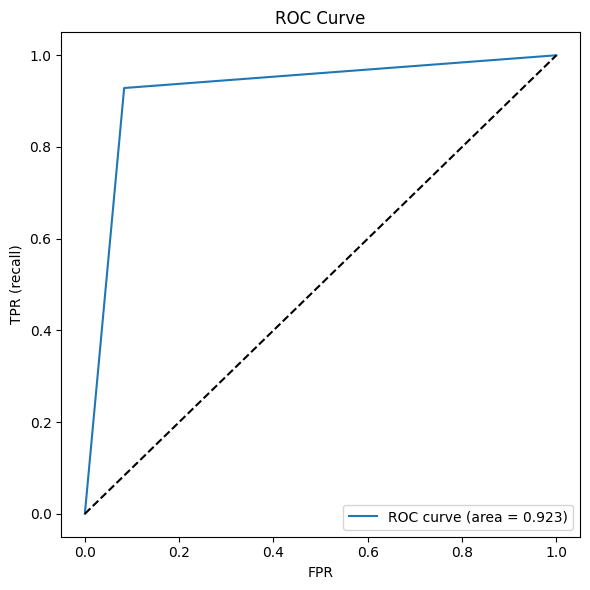

In [15]:
# Probabilidades para test
y_test_proba = dt_default.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR (recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Parte (j)

In [16]:
param_grid = {
    'criterion': ['gini','entropy','log_loss'],
    'min_samples_leaf': [1,2,10],
    'max_depth': [2,5,15]
}

dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(dt, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

# Evaluar en train/test
y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)
y_test_proba_best = best_model.predict_proba(X_test)[:,1]

print("Train: AUC, Accuracy, F1",
      roc_auc_score(y_train, best_model.predict_proba(X_train)[:,1]),
      accuracy_score(y_train, y_train_pred_best),
      f1_score(y_train, y_train_pred_best))

print("Test: AUC, Accuracy, F1",
      roc_auc_score(y_test, y_test_proba_best),
      accuracy_score(y_test, y_test_pred_best),
      f1_score(y_test, y_test_pred_best))


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}
Train: AUC, Accuracy, F1 0.9929411764705882 0.9582417582417583 0.9422492401215805
Test: AUC, Accuracy, F1 0.9902447089947091 0.9473684210526315 0.925


## Parte (k)

perimeter_worst           0.828201
concave points_worst      0.110933
texture_worst             0.026577
area_se                   0.016736
concave points_mean       0.008847
fractal_dimension_se      0.008705
compactness_mean          0.000000
smoothness_mean           0.000000
symmetry_mean             0.000000
concavity_mean            0.000000
perimeter_mean            0.000000
area_mean                 0.000000
radius_mean               0.000000
texture_mean              0.000000
perimeter_se              0.000000
texture_se                0.000000
radius_se                 0.000000
fractal_dimension_mean    0.000000
concave points_se         0.000000
concavity_se              0.000000
dtype: float64


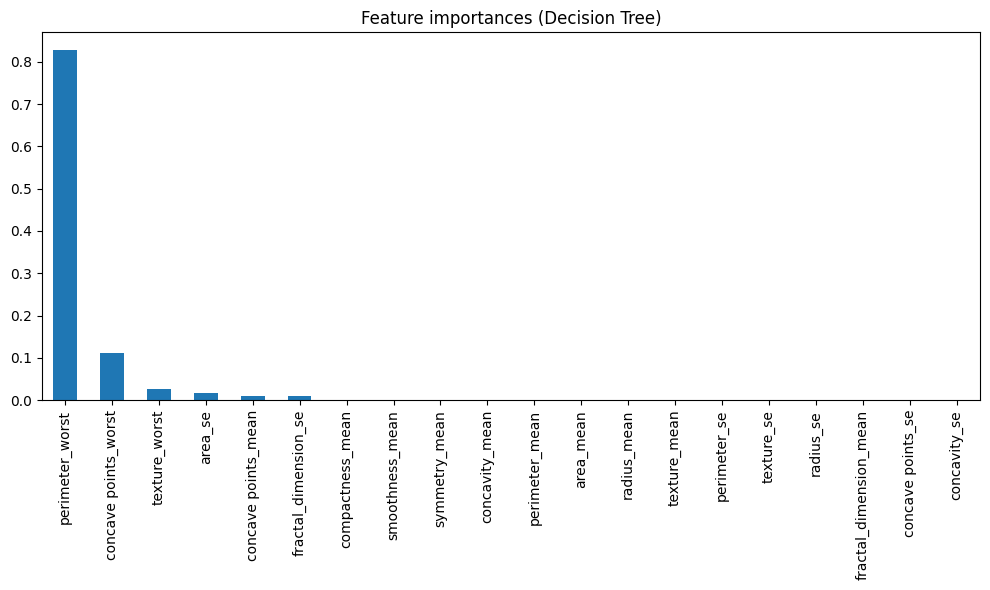

In [ ]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Mostrar top 20
print(feat_imp.head(20))

plt.figure(figsize=(10,6))
feat_imp.head(20).plot(kind='bar')
plt.title('Feature importances (Decision Tree)')
plt.tight_layout()
plt.show()


## Parte (l)

In [18]:
# Añadir labels_km al dataset original
df = pd.read_csv(csv_local)

# drop id and unnamed 32:
df = df.drop(columns=['id'])
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df_with_k = df.copy()

df_with_k['kmeans_label'] = labels_km

# Incluir como variable categórica
X_with_k = df_with_k.select_dtypes(include=[np.number]).copy()
X_with_k = pd.get_dummies(df_with_k.drop(columns=['diagnosis']), columns=['kmeans_label'], prefix='kmean')

# Preparar X e Y
y_all = df_with_k['diagnosis'].map(lambda x: 1 if x.lower().startswith('m') or 'mal' in x.lower() else 0)

# Validación cruzada con y sin la nueva característica
dt_simple = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5)  

# Sin kmeans labels
X_nok = df.select_dtypes(include=[np.number]).copy()
scores_nok = cross_val_score(dt_simple, X_nok, y_all, cv=5, scoring='f1')

# Con kmeans labels 
X_withk = pd.get_dummies(df_with_k.drop(columns=['diagnosis']), columns=['kmeans_label'], prefix='kmean')
scores_withk = cross_val_score(dt_simple, X_withk, y_all, cv=5, scoring='f1')

print("F1 CV mean sin kmeans:", scores_nok.mean())
print("F1 CV mean con kmeans:", scores_withk.mean())

F1 CV mean sin kmeans: 0.8929229578010066
F1 CV mean con kmeans: 0.8975740202585648


# Modelos basados en árboles, profundización

## Parte (n)

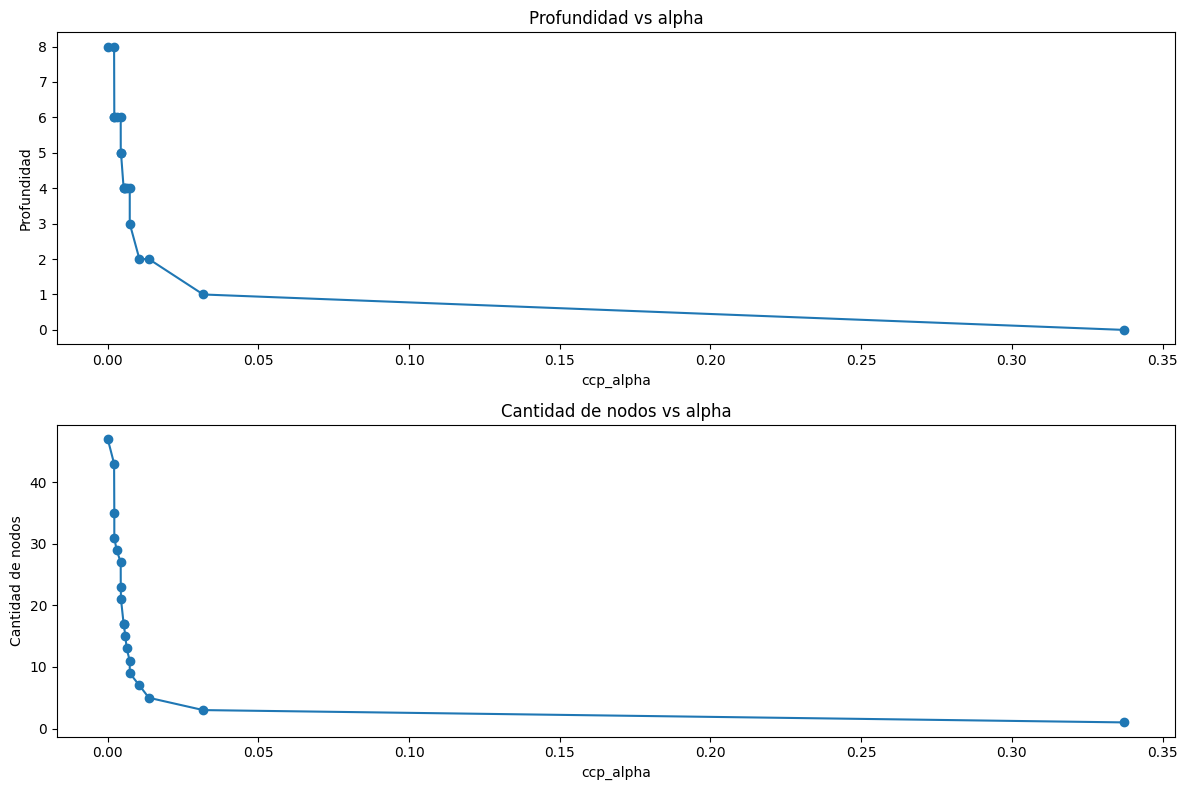

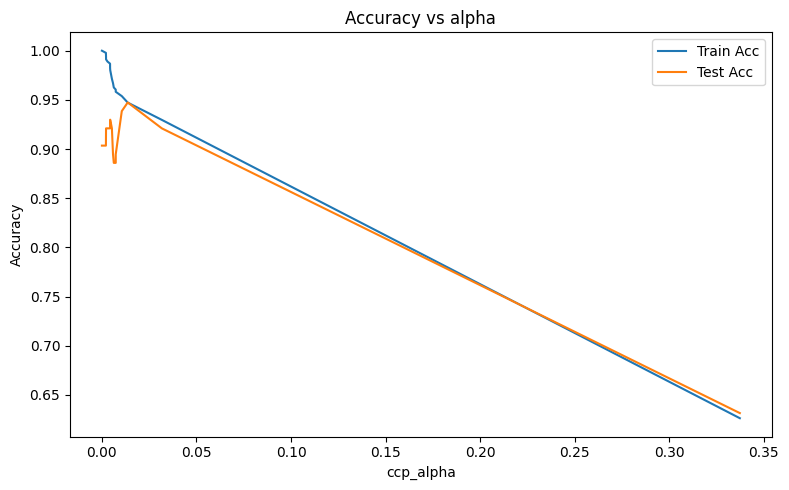

Mejor alpha por test_acc: 0.0136443081007947


In [ ]:
path = dt_default.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

# Entrenar árboles para cada alpha
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# profundidad y n_nodos
depths = [clf.get_depth() for clf in clfs]
node_counts = [clf.tree_.node_count for clf in clfs]

# Accuracy en train y validación para cada alpha
train_acc = [accuracy_score(y_train, clf.predict(X_train)) for clf in clfs]
test_acc = [accuracy_score(y_test, clf.predict(X_test)) for clf in clfs]

# Graficar
plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
plt.plot(ccp_alphas, depths, marker='o')
plt.xlabel('ccp_alpha'); plt.ylabel('Profundidad'); plt.title('Profundidad vs alpha')

plt.subplot(2,1,2)
plt.plot(ccp_alphas, node_counts, marker='o')
plt.xlabel('ccp_alpha'); plt.ylabel('Cantidad de nodos'); plt.title('Cantidad de nodos vs alpha')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_acc, label='Train Acc')
plt.plot(ccp_alphas, test_acc, label='Test Acc')
plt.xlabel('ccp_alpha'); plt.ylabel('Accuracy'); plt.legend()
plt.title('Accuracy vs alpha')
plt.tight_layout()
plt.show()

# alpha que maximiza test_acc
best_idx = np.argmax(test_acc)
best_alpha = ccp_alphas[best_idx]
print("Mejor alpha por test_acc:", best_alpha)
pruned_tree = clfs[best_idx]


In [20]:
# train y test accuracy para el alpha optimo
y_train_pred_pruned = pruned_tree.predict(X_train)
y_test_pred_pruned = pruned_tree.predict(X_test)
print("Pruned Tree Train Accuracy:", accuracy_score(y_train, y_train_pred_pruned))
print("Pruned Tree Test Accuracy:", accuracy_score(y_test, y_test_pred_pruned))

Pruned Tree Train Accuracy: 0.9472527472527472
Pruned Tree Test Accuracy: 0.9473684210526315


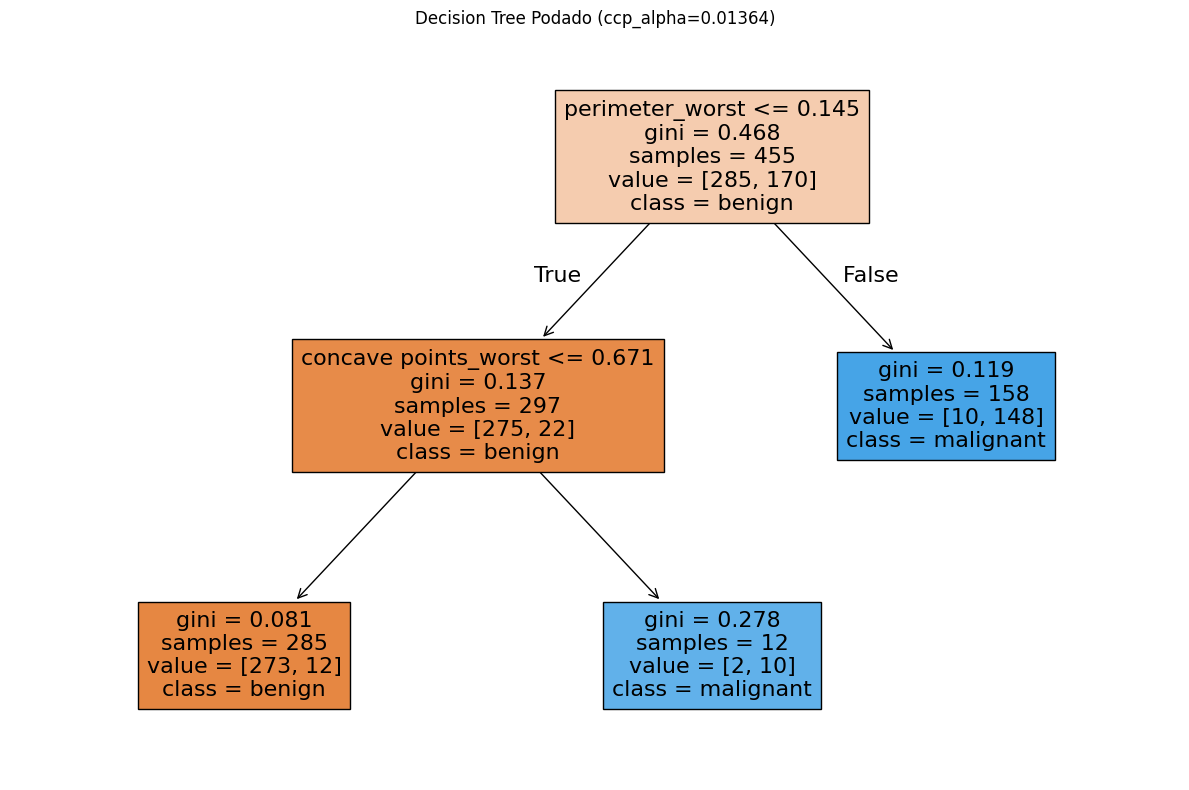

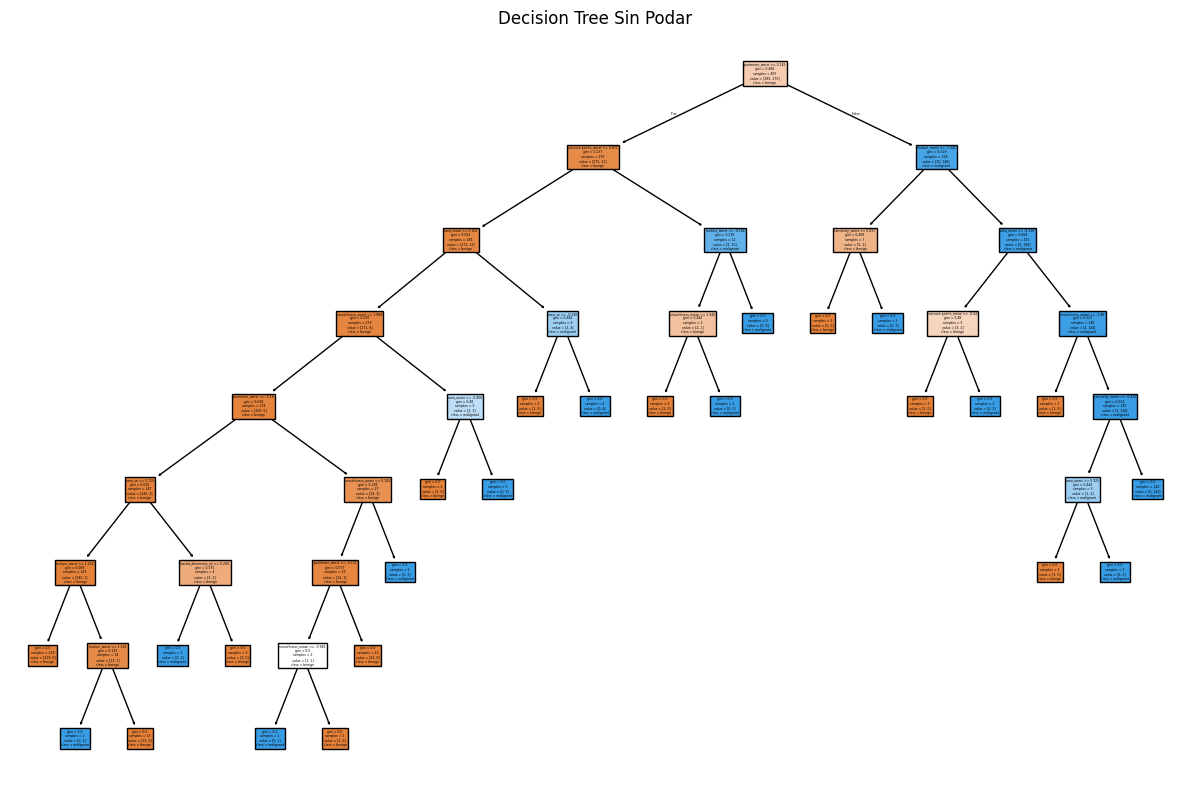

In [21]:
# Graficar arbol podado con alpha óptimo
plt.figure(figsize=(12,8))
plot_tree(pruned_tree, feature_names=feature_names, class_names=['benign','malignant'], filled=True)
plt.title(f'Decision Tree Podado (ccp_alpha={best_alpha:.5f})')
plt.tight_layout()

# graficar arbol sin podar
plt.figure(figsize=(12,8))
plot_tree(dt_default, feature_names=feature_names, class_names=['benign','malignant'], filled=True)
plt.title('Decision Tree Sin Podar')
plt.tight_layout()
plt.show()

## Parte (ñ)

In [22]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
bag.fit(X_train, y_train)
print("Bagging train accuracy:", accuracy_score(y_train, bag.predict(X_train)))
print("Bagging test accuracy:", accuracy_score(y_test, bag.predict(X_test)))

# Random Forest
rf = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
print("Random Forest train accuracy:", accuracy_score(y_train, rf.predict(X_train)))
print("Random Forest test accuracy:", accuracy_score(y_test, rf.predict(X_test)))

Bagging train accuracy: 1.0
Bagging test accuracy: 0.9736842105263158
Random Forest train accuracy: 1.0
Random Forest test accuracy: 0.9736842105263158


## Parte (o)

Gini importances RandomForest:
concave points_worst    0.109992
concave points_mean     0.104194
area_worst              0.102906
radius_worst            0.099437
perimeter_mean          0.083051
perimeter_worst         0.077482
radius_mean             0.062782
area_mean               0.048824
concavity_mean          0.048072
concavity_worst         0.046118
area_se                 0.039977
radius_se               0.023394
compactness_mean        0.019076
compactness_worst       0.017881
perimeter_se            0.015849
texture_worst           0.014711
texture_mean            0.012925
smoothness_worst        0.011743
symmetry_worst          0.009184
fractal_dimension_se    0.006209
dtype: float64
Permutation importances RandomForest:
concave points_worst      0.024561
area_worst                0.019298
fractal_dimension_mean    0.007018
radius_se                 0.005263
area_se                   0.005263
concave points_mean       0.004386
area_mean                 0.004386
texture_wor

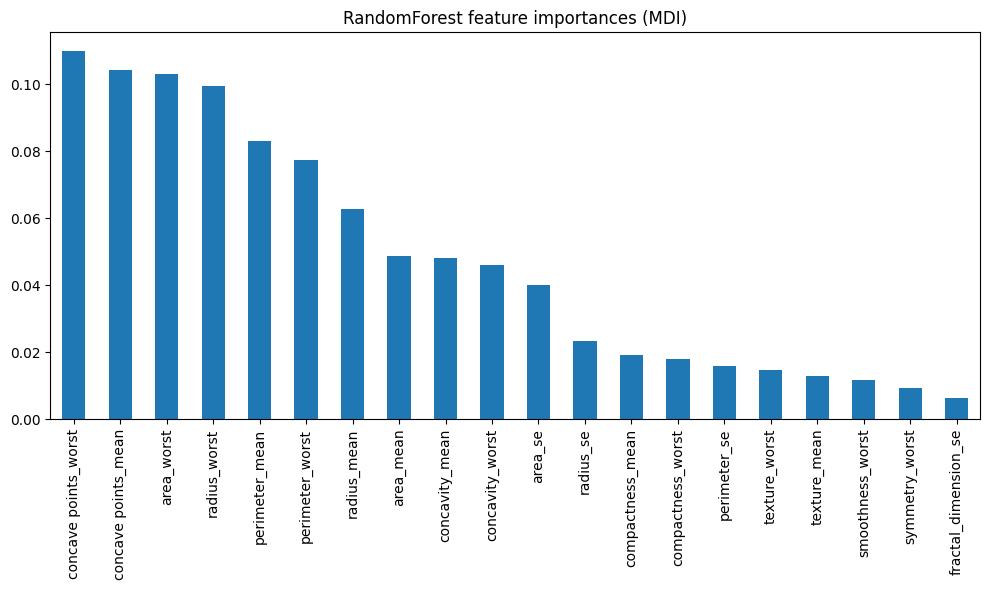

In [ ]:
# Gini importances
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Gini importances RandomForest:")
print(rf_imp.head(20))

# Permutation importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_importances = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
print("Permutation importances RandomForest:")
print(perm_importances.head(20))

## Parte (p)

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

results = []
for max_depth in [1,2,3,5,6,7,8,9,10]:
    gbc = GradientBoostingClassifier(n_estimators=100, max_depth=max_depth, random_state=RANDOM_STATE)
    gbc.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, gbc.predict(X_train))
    test_acc = accuracy_score(y_test, gbc.predict(X_test))
    results.append((max_depth, train_acc, test_acc))

results_df = pd.DataFrame(results, columns=['max_depth','train_acc','test_acc'])
print(results_df)

print("Bagging test acc:", accuracy_score(y_test, bag.predict(X_test)))
print("RF test acc:", accuracy_score(y_test, rf.predict(X_test)))


   max_depth  train_acc  test_acc
0          1   0.989011  0.982456
1          2   1.000000  0.982456
2          3   1.000000  0.982456
3          5   1.000000  0.938596
4          6   1.000000  0.929825
5          7   1.000000  0.921053
6          8   1.000000  0.921053
7          9   1.000000  0.921053
8         10   1.000000  0.921053
Bagging test acc: 0.9736842105263158
RF test acc: 0.9736842105263158


## Parte (q)

     n   Bagging  Random Forest  Gradient Boost
0   10  0.956140       0.973684        0.956140
1   25  0.964912       0.973684        0.964912
2   50  0.973684       0.973684        0.973684
3   75  0.964912       0.964912        0.982456
4  100  0.964912       0.964912        0.982456
5  125  0.964912       0.964912        0.982456
6  150  0.964912       0.964912        0.982456
7  175  0.964912       0.964912        0.964912
8  200  0.964912       0.964912        0.964912


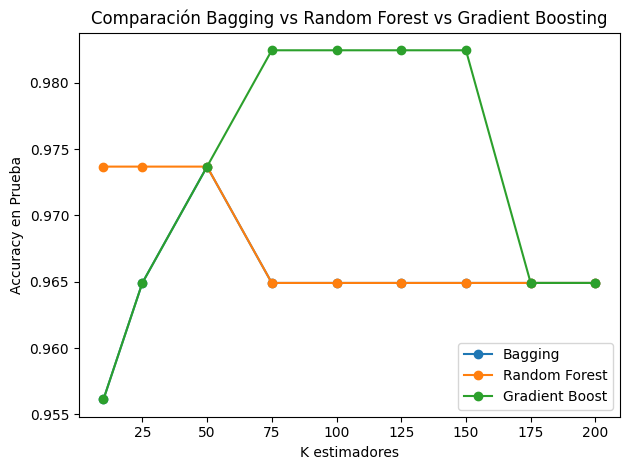

In [25]:
n_list = [10, 25, 50, 75, 100, 125, 150, 175, 200]
results = []
for n in n_list:
    bag_n = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    rf_n = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    gbc_n = GradientBoostingClassifier(n_estimators=n, random_state=RANDOM_STATE)

    bag_n.fit(X_train, y_train)
    rf_n.fit(X_train, y_train)
    gbc_n.fit(X_train, y_train)

    results.append({
        'n': n,
        'Bagging': accuracy_score(y_test, bag_n.predict(X_test)),
        'Random Forest': accuracy_score(y_test, rf_n.predict(X_test)),
        'Gradient Boost': accuracy_score(y_test, gbc_n.predict(X_test))
    })

res_df = pd.DataFrame(results)
print(res_df)

# comparación
res_df.set_index('n').plot(marker='o')
plt.xlabel('K estimadores')
plt.ylabel('Accuracy en Prueba')
plt.title('Comparación Bagging vs Random Forest vs Gradient Boosting')
plt.tight_layout()
plt.show()


# Generalización

In [26]:
csv_local = "data.csv"  

df = pd.read_csv(csv_local)

# drop id and unnamed 32:
df = df.drop(columns=['id'])
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

X_all = df.select_dtypes(include=[np.number]).copy()

y = df['diagnosis'].map(lambda x: 1 if x.lower().startswith('m') or 'mal' in x.lower() else 0).values

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

## Parte (r)

In [28]:
# RobustScaler
rs = RobustScaler()
rs.fit(X_train)
X_train_rs = rs.transform(X_train)
X_test_rs = rs.transform(X_test)

# StandardScaler
ss = StandardScaler()
ss.fit(X_train)
X_train_ss = ss.transform(X_train)
X_test_ss = ss.transform(X_test)

## Parte (s)

In [ ]:
clf_orig = GradientBoostingClassifier(n_estimators=75, max_depth=1 , random_state=RANDOM_STATE)
clf_rs = GradientBoostingClassifier(n_estimators=75, max_depth=1, random_state=RANDOM_STATE)
clf_ss = GradientBoostingClassifier(n_estimators=75, max_depth=1, random_state=RANDOM_STATE)

clf_orig.fit(X_train, y_train)
clf_rs.fit(X_train_rs, y_train)
clf_ss.fit(X_train_ss, y_train)

# Predict train
f1_orig_train = f1_score(y_train, clf_orig.predict(X_train))
f1_rs_train = f1_score(y_train, clf_rs.predict(X_train_rs))
f1_ss_train = f1_score(y_train, clf_ss.predict(X_train_ss))

print("F1 scores on Train set:")
print("F1 original:", f1_orig_train)
print("F1 RobustScaler:", f1_rs_train)
print("F1 StandardScaler:", f1_ss_train)

# Predict test
f1_orig = f1_score(y_test, clf_orig.predict(X_test))
f1_rs = f1_score(y_test, clf_rs.predict(X_test_rs))
f1_ss = f1_score(y_test, clf_ss.predict(X_test_ss))

# F1 scores test
print("F1 scores on Test set:")
print("F1 original:", f1_orig)
print("F1 RobustScaler:", f1_rs) 
print("F1 StandardScaler:", f1_ss)


F1 scores on Train set:
F1 original: 0.9791044776119403
F1 RobustScaler: 0.9791044776119403
F1 StandardScaler: 0.9791044776119403
F1 scores on Test set:
F1 original: 0.95
F1 RobustScaler: 0.95
F1 StandardScaler: 0.95
